In [ ]:
import pandas as pd;
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [129]:
df = pd.read_csv('../../data/Titanic-Dataset.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [130]:
# Dataset Information 
df.info()
# Empty cells in the dataset can be identified using the isnull() function. This function returns a DataFrame with the same shape as df, but with boolean values indicating whether each cell is null (True) or not (False).
df.isnull()
# returns a tuple representing the dimensionality of the DataFrame. The first element of the tuple is the number of rows, and the second element is the number of columns.
df.shape
#
df.columns



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [131]:
#Analysing the data

df.info()

# The dataset has 177 passengers without ages, 687 passengers without cabin numbers, and 2 passengers without embarkation information. The rest of the columns have no missing values. We can also see that the dataset has 12 columns and 891 rows.
# 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [132]:

# ============================================
# Handling missing values in the Age column
# ============================================

# Display the median age
display("Median age:")
display(df['Age'].median())

# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Check how many missing values remain in the Age column
display("Number of missing values in Age after filling:")
display(df['Age'].isna().sum())


# ============================================
# Handling missing values in the Embarked column
# ============================================

# Display the Embarked column before filling missing values
display("Embarked column:")
display(df['Embarked'])

# Calculate and display the most frequent value (mode)
display("Most frequent value (mode) of the Embarked column:")
mode = df['Embarked'].mode()
display(mode[0])

# Fill missing Embarked values with the most frequent value
df['Embarked'] = df['Embarked'].fillna(mode[0])

# Display the Embarked column after filling missing values
display("Embarked column after filling missing values:")
display(df['Embarked'])

# Check how many missing values remain in the Embarked column
display("Number of missing values in Embarked after filling:")
display(df['Embarked'].isna().sum())

# Delete the Cabin column.

df.drop('Cabin', axis=1, inplace=True)


df.head(10)











'Median age:'

np.float64(28.0)

'Number of missing values in Age after filling:'

np.int64(0)

'Embarked column:'

...

'Embarked column after filling missing values:'

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

'Number of missing values in Embarked after filling:'

np.int64(0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [133]:

df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df['Embarked'] = df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

display("Data types after encoding:")
display(df.dtypes)

display("First 10 rows after encoding:")
display(df.head(10))



'Data types after encoding:'

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked         int64
dtype: object

'First 10 rows after encoding:'

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,2
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,1


'Graph1 DataFrame:'

<Axes: xlabel='Pclass'>

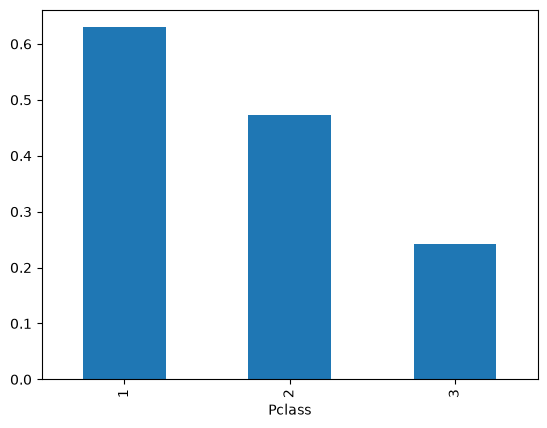

In [134]:
survival_rate = df.groupby('Pclass')['Survived'].mean()
ax = survival_rate.plot.bar()

display("Graph1 DataFrame:")
display(ax)



'Graph2 DataFrame:'

<Axes: title={'center': 'Passenger Age Distribution'}, xlabel='Age', ylabel='Number of passengers'>

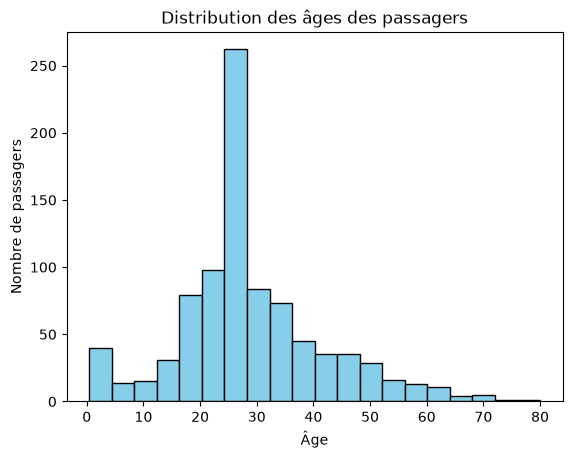

In [135]:
ax = df['Age'].plot.hist(bins=20, color='skyblue', edgecolor='black')

# 2. Add titles and labels to make the chart clear.
ax.set_title("Passenger Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Number of passengers")

display("Graph2 DataFrame:")
display(ax)

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Separate X and y.
y = df['Survived']
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])

# 2. Create a clean 80% train / 20% test split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and train the model.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Predict on the test set.
survived_pred = model.predict(X_test)

# 5. Display the results.
display("First 10 predictions on the test set:")
display(survived_pred[:10])

precision = accuracy_score(y_test, survived_pred)

print(f"Model accuracy: {precision * 100:.2f}%")



'First 10 predictions on the test set:'

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

Model accuracy: 79.89%


In [146]:
# 1. Family size (passenger + siblings/spouses + parents/children).
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Extract the title from the name (for example: "Braund, Mr. Owen Harris" -> "Mr").
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Group rare titles to simplify the feature.
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Encode the title as a numeric feature.
df['Title'] = df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\oussa\AppData\Local\Temp\ipykernel_31664\2419558876.py:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
